# Chapter 10. Data Aggregation and Group Operations
- After loading, merging, and preparing a dataset, you may need to compute group satistics or possibly *pivot tables** for reporting or visualization purposes.
- Pandas provides a flexible ***groupby*** interface, enabling you to slice, dice, and summarize datasets in a natural way.

> - **Split a pandas object** into pieces using one or more keys (in the form of **functions, arrays, or DataFrame column names**)
> - **Calculate group summary statistics**, like count, mean, or standard deviation, or a user-defined function
> - Apply **within-group** transformations or other manipulations, like **normalization, linear regression, rank, or subset selection**
> - Compute pivot tables and cross-tabulations
> - Perform **quantile analysis** and other statistical group analyses

In [2]:
import pandas as pd
import numpy as np

## 10.2 Data Aggregation
- Aggregation refer to any data transformation that produces scalar values from arrays.
>> 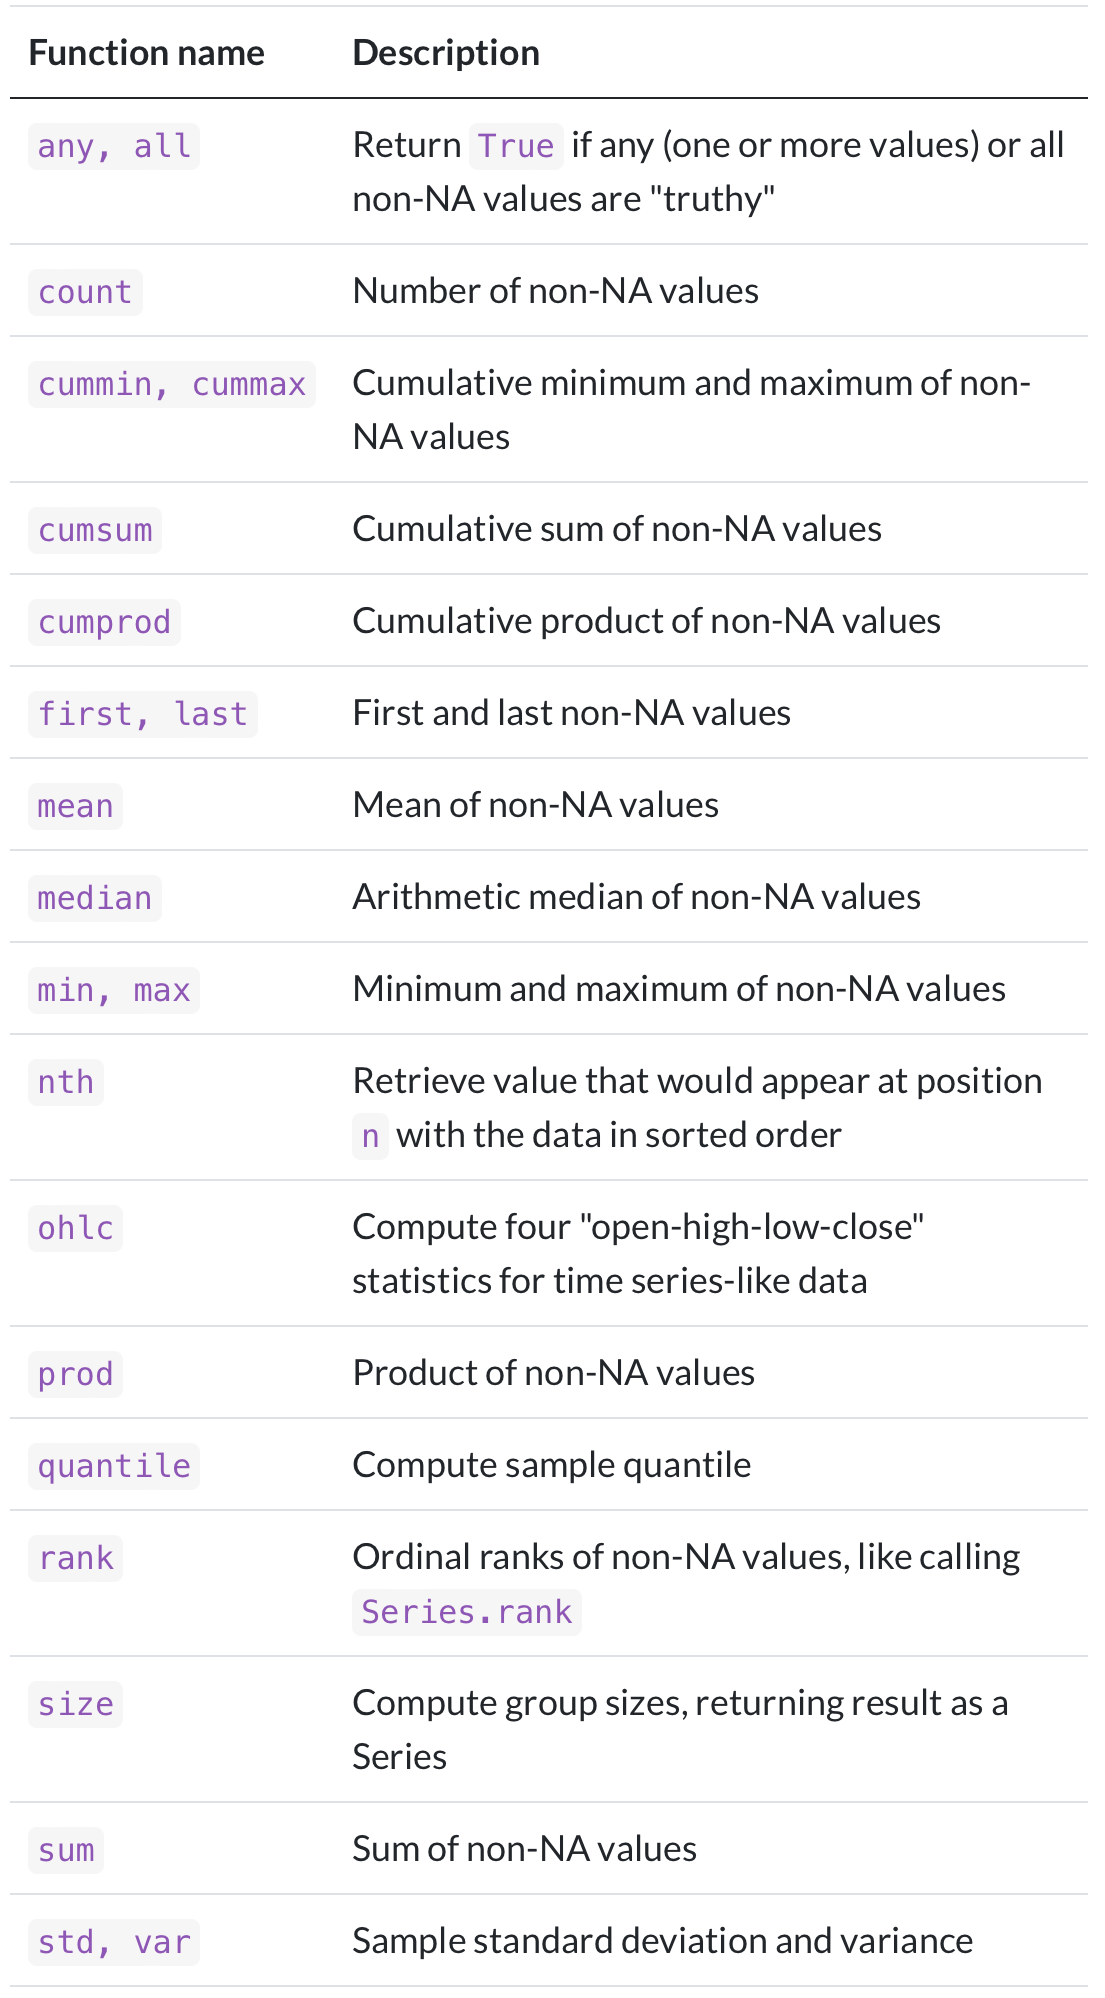
- While ***nsmallest*** is not explicitly implemented for GroupBy, we can still use it with a **nonoptimized implementation**. Internally, GroupBy efficiently slices up the Series, calls ***piece.nsmallest(n)*** for each piece, and then assembles those results together into the result object:

In [12]:
df

,key1,key2,data1,data2
0,a,one,0.543853,-0.105208
1,a,two,0.911211,-0.014443
2,None,one,0.822253,-1.207510
3,b,two,-0.033491,0.173178
4,b,one,1.419342,-1.510191
5,a,None,0.178249,1.292756
6,None,one,-2.538606,1.403690


In [13]:
grouped = df.groupby('key1')
grouped['data1'].nsmallest(2)

key1   
a     5    0.178249
      0    0.543853
b     3   -0.033491
      4    1.419342
Name: data1, dtype: float64

> - To use own aggregation functions, pass any function that aggregates an array to the ***aggregate*** method or its short alias ***agg*** method:
> - Custom aggregation functions are generally much slower than the optimized functions.

In [15]:
def peak_to_peak(arr):
    return arr.max() - arr.min()

grouped.agg(peak_to_peak)

/private/var/mobile/Containers/Data/Application/0A23D722-1D20-4919-BF07-2451C9C92FD8/tmp/ipykernel_1700/1321513124.py:4: FutureWarning: ['key2'] did not aggregate successfully. If any error is raised this will raise in a future version of pandas. Drop these columns/ops to avoid this warning.
  grouped.agg(peak_to_peak)


,data1,data2
key1,,
a,0.732962,1.397965
b,1.452833,1.683369


In [16]:
grouped.describe()

data1                                                              \
     count      mean       std       min       25%       50%       75%   
key1                                                                     
a      3.0  0.544438  0.366481  0.178249  0.361051  0.543853  0.727532   
b      2.0  0.692926  1.027308 -0.033491  0.329717  0.692926  1.056134   

               data2                                                    \
           max count      mean       std       min       25%       50%   
key1                                                                     
a     0.911211   3.0  0.391035  0.782231 -0.105208 -0.059826 -0.014443   
b     1.419342   2.0 -0.668507  1.190322 -1.510191 -1.089349 -0.668507   

                          
           75%       max  
key1                      
a     0.639156  1.292756  
b    -0.247664  0.173178

### Column-Wise and Multiple Functions Application

In [17]:
tips = pd.read_csv('Examples/tips.csv')

# Add tip percentage of total bill
tips['tip_pct'] = tips['tip']/tips['total_bill']
tips.head()

,total_bill,tip,smoker,day,time,size,tip_pct
0,16.99,1.01,No,Sun,Dinner,2,0.059447
1,10.34,1.66,No,Sun,Dinner,3,0.160542
2,21.01,3.50,No,Sun,Dinner,3,0.166587
3,23.68,3.31,No,Sun,Dinner,2,0.139780
4,24.59,3.61,No,Sun,Dinner,4,0.146808


> - You may want to aggregate using a different function, dependign on the column, or multiple functions at once.

In [18]:
grouped = tips.groupby(['day','smoker'])

In [19]:
grouped_pct = grouped['tip_pct']

In [20]:
grouped_pct.agg('mean')

day   smoker
Fri   No        0.151650
      Yes       0.174783
Sat   No        0.158048
      Yes       0.147906
Sun   No        0.160113
      Yes       0.187250
Thur  No        0.160298
      Yes       0.163863
Name: tip_pct, dtype: float64

> - If you pass **a list of functions or function names** instead, you get back a DataFrame with column names taken from the functions:

In [21]:
grouped_pct.agg(['mean','std',peak_to_peak])

mean       std  peak_to_peak
day  smoker                                  
Fri  No      0.151650  0.028123      0.067349
     Yes     0.174783  0.051293      0.159925
Sat  No      0.158048  0.039767      0.235193
     Yes     0.147906  0.061375      0.290095
Sun  No      0.160113  0.042347      0.193226
     Yes     0.187250  0.154134      0.644685
Thur No      0.160298  0.038774      0.193350
     Yes     0.163863  0.039389      0.151240

> - If you pass a list of ***(name, function)* tuples**, the first element of each tuple will be used as the DataFrame column names:

In [24]:
grouped_pct.agg([('average','mean'),('표준편차','std')])

average      표준편차
day  smoker                    
Fri  No      0.151650  0.028123
     Yes     0.174783  0.051293
Sat  No      0.158048  0.039767
     Yes     0.147906  0.061375
Sun  No      0.160113  0.042347
     Yes     0.187250  0.154134
Thur No      0.160298  0.038774
     Yes     0.163863  0.039389

> - You can specify a list of functions **to apply to all of the columns or different functions per column**. 

In [27]:
functions = ['count','mean','max']

In [34]:
result = grouped[['tip_pct','total_bill']].agg(functions)
result

tip_pct                     total_bill                  
              count      mean       max      count       mean    max
day  smoker                                                         
Fri  No           4  0.151650  0.187735          4  18.420000  22.75
     Yes         15  0.174783  0.263480         15  16.813333  40.17
Sat  No          45  0.158048  0.291990         45  19.661778  48.33
     Yes         42  0.147906  0.325733         42  21.276667  50.81
Sun  No          57  0.160113  0.252672         57  20.506667  48.17
     Yes         19  0.187250  0.710345         19  24.120000  45.35
Thur No          45  0.160298  0.266312         45  17.113111  41.19
     Yes         17  0.163863  0.241255         17  19.190588  43.11

> - As before, a list of tuples with custom names can be passed:

In [33]:
ftuples = [('Average','mean'), ('Variance',np.var)]
grouped[['tip_pct','total_bill']].agg(ftuples)

tip_pct           total_bill            
              Average  Variance    Average    Variance
day  smoker                                           
Fri  No      0.151650  0.000791  18.420000   25.596333
     Yes     0.174783  0.002631  16.813333   82.562438
Sat  No      0.158048  0.001581  19.661778   79.908965
     Yes     0.147906  0.003767  21.276667  101.387535
Sun  No      0.160113  0.001793  20.506667   66.099980
     Yes     0.187250  0.023757  24.120000  109.046044
Thur No      0.160298  0.001503  17.113111   59.625081
     Yes     0.163863  0.001551  19.190588   69.808518

> - Suppose you want to apply potentially **different functions to one or more of the columns**. 
> - To do this, pass a dictionary to agg that contains a **mapping of column names to any of the function specifications listed** so far:

In [16]:
grouped.agg({'tip_pct':['min','max','mean','std'],
             'size':'sum'})

tip_pct                               size
                  min       max      mean       std  sum
day  smoker                                             
Fri  No      0.120385  0.187735  0.151650  0.028123    9
     Yes     0.103555  0.263480  0.174783  0.051293   31
Sat  No      0.056797  0.291990  0.158048  0.039767  115
     Yes     0.035638  0.325733  0.147906  0.061375  104
Sun  No      0.059447  0.252672  0.160113  0.042347  167
     Yes     0.065660  0.710345  0.187250  0.154134   49
Thur No      0.072961  0.266312  0.160298  0.038774  112
     Yes     0.090014  0.241255  0.163863  0.039389   40

### Returning Aggregated Data without Row Indexes
- You can disable index in most cases by passing ***as_index=False* to groupby**:

In [17]:
tips.groupby(['day','smoker'], as_index=False).mean()

,day,smoker,total_bill,tip,size,tip_pct
0,Fri,No,18.420000,2.812500,2.250000,0.151650
1,Fri,Yes,16.813333,2.714000,2.066667,0.174783
2,Sat,No,19.661778,3.102889,2.555556,0.158048
3,Sat,Yes,21.276667,2.875476,2.476190,0.147906
4,Sun,No,20.506667,3.167895,2.929825,0.160113
5,Sun,Yes,24.120000,3.516842,2.578947,0.187250
6,Thur,No,17.113111,2.673778,2.488889,0.160298
7,Thur,Yes,19.190588,3.030000,2.352941,0.163863


- Of course, it's always possible to obtain the result in this format by calling *reset_index* on the result.

## 10.3 Apply: Genral split-apply-combine
- ***apply*** **splits** the object being manipulated **into pieces**, **invokes the passed function on each piece**, and then attempts to **concatenate the pieces together**

In [19]:
def top(df, n=5, column='tip_pct'):
    return df.sort_values(column, ascending=False)[:n]

In [20]:
top(tips, n=6)

,total_bill,tip,smoker,day,time,size,tip_pct
172,7.25,5.15,Yes,Sun,Dinner,2,0.710345
178,9.60,4.00,Yes,Sun,Dinner,2,0.416667
67,3.07,1.00,Yes,Sat,Dinner,1,0.325733
232,11.61,3.39,No,Sat,Dinner,2,0.291990
183,23.17,6.50,Yes,Sun,Dinner,4,0.280535
109,14.31,4.00,Yes,Sat,Dinner,2,0.279525


In [21]:
tips.groupby('smoker').apply(top)

total_bill   tip smoker   day    time  size   tip_pct
smoker                                                           
No     232       11.61  3.39     No   Sat  Dinner     2  0.291990
       149        7.51  2.00     No  Thur   Lunch     2  0.266312
       51        10.29  2.60     No   Sun  Dinner     2  0.252672
       185       20.69  5.00     No   Sun  Dinner     5  0.241663
       88        24.71  5.85     No  Thur   Lunch     2  0.236746
Yes    172        7.25  5.15    Yes   Sun  Dinner     2  0.710345
       178        9.60  4.00    Yes   Sun  Dinner     2  0.416667
       67         3.07  1.00    Yes   Sat  Dinner     1  0.325733
       183       23.17  6.50    Yes   Sun  Dinner     4  0.280535
       109       14.31  4.00    Yes   Sat  Dinner     2  0.279525

1. The **tips** DataFrame is **split into groups** based on the value of **'smoker'**.
2. The **top** function is called **on each group**.
3. The results of each function call are **glued together** using ***pandas.concat***, labeling the pieces with the group names.

In [22]:
tips.groupby(['smoker','day']).apply(top, n=1, column='total_bill')

total_bill    tip smoker   day    time  size   tip_pct
smoker day                                                             
No     Fri  94        22.75   3.25     No   Fri  Dinner     2  0.142857
       Sat  212       48.33   9.00     No   Sat  Dinner     4  0.186220
       Sun  156       48.17   5.00     No   Sun  Dinner     6  0.103799
       Thur 142       41.19   5.00     No  Thur   Lunch     5  0.121389
Yes    Fri  95        40.17   4.73    Yes   Fri  Dinner     4  0.117750
       Sat  170       50.81  10.00    Yes   Sat  Dinner     3  0.196812
       Sun  182       45.35   3.50    Yes   Sun  Dinner     3  0.077178
       Thur 197       43.11   5.00    Yes  Thur   Lunch     4  0.115982

> - The resulting object has a hierarchical index formed from the group keys, along with the indexes of each piece of the original object.
> - You can disable this by ***group_keys=False*** to ***groupby***:

In [23]:
tips.groupby('smoker', group_keys=False).apply(top)

,total_bill,tip,smoker,day,time,size,tip_pct
232,11.61,3.39,No,Sat,Dinner,2,0.291990
149,7.51,2.00,No,Thur,Lunch,2,0.266312
51,10.29,2.60,No,Sun,Dinner,2,0.252672
185,20.69,5.00,No,Sun,Dinner,5,0.241663
88,24.71,5.85,No,Thur,Lunch,2,0.236746
172,7.25,5.15,Yes,Sun,Dinner,2,0.710345
178,9.60,4.00,Yes,Sun,Dinner,2,0.416667
67,3.07,1.00,Yes,Sat,Dinner,1,0.325733
183,23.17,6.50,Yes,Sun,Dinner,4,0.280535
109,14.31,4.00,Yes,Sat,Dinner,2,0.279525


### Quantile and Bucket Analysis

> - An **equal-length bucket** categorization using ***cut***:

In [2]:
frame = pd.DataFrame({'data1':np.random.standard_normal(1000),
                      'data2':np.random.standard_normal(1000)})
frame.head()

,data1,data2
0,-2.111119,-0.752591
1,0.721147,-1.244935
2,-0.015531,-0.535101
3,1.225057,1.410940
4,-0.940992,-1.339498


In [3]:
quartiles = pd.cut(frame['data1'],4)
quartiles.head(10)

0    (-3.56, -1.967]
1     (-0.38, 1.206]
2     (-0.38, 1.206]
3     (1.206, 2.793]
4    (-1.967, -0.38]
5    (-1.967, -0.38]
6     (-0.38, 1.206]
7     (-0.38, 1.206]
8    (-1.967, -0.38]
9    (-1.967, -0.38]
Name: data1, dtype: category
Categories (4, interval[float64, right]): [(-3.56, -1.967] < (-1.967, -0.38] < (-0.38, 1.206] < (1.206, 2.793]]

In [4]:
def get_stats(group):
    return pd.DataFrame({'min':group.min(), 'max':group.max(),
                         'count':group.count(), 'mean':group.mean()})

In [5]:
grouped = frame.groupby(quartiles)
grouped.apply(get_stats)

min       max  count      mean
data1                                                     
(-3.56, -1.967] data1 -3.554123 -1.978454     20 -2.364058
                data2 -3.207985  1.439094     20 -0.094653
(-1.967, -0.38] data1 -1.954415 -0.382170    347 -1.006903
                data2 -3.452427  2.603739    347  0.001919
(-0.38, 1.206]  data1 -0.375010  1.185802    532  0.313997
                data2 -2.644631  3.170603    532 -0.005150
(1.206, 2.793]  data1  1.219921  2.793133    101  1.724576
                data2 -2.371336  3.559619    101 -0.040301

> - Keep in mind the same result could have been computed more simply with:

In [6]:
grouped.agg(['min','max','count','mean'])

data1                               data2                  \
                      min       max count      mean       min       max count   
data1                                                                           
(-3.56, -1.967] -3.554123 -1.978454    20 -2.364058 -3.207985  1.439094    20   
(-1.967, -0.38] -1.954415 -0.382170   347 -1.006903 -3.452427  2.603739   347   
(-0.38, 1.206]  -0.375010  1.185802   532  0.313997 -2.644631  3.170603   532   
(1.206, 2.793]   1.219921  2.793133   101  1.724576 -2.371336  3.559619   101   

                           
                     mean  
data1                      
(-3.56, -1.967] -0.094653  
(-1.967, -0.38]  0.001919  
(-0.38, 1.206]  -0.005150  
(1.206, 2.793]  -0.040301

> - To compute **equal-size buckets** based on sample quatiles, use ***qcut***. 

In [11]:
quartiles_samp = pd.qcut(frame['data1'], 4, labels=False)
quartiles_samp.head()

0    0
1    3
2    2
3    3
4    0
Name: data1, dtype: int64

- Passing ***labels=False*** to obtain just the quartile indices instead of intervals.

In [12]:
grouped = frame.groupby(quartiles_samp)
grouped.apply(get_stats)

min       max  count      mean
data1                                           
0     data1 -3.554123 -0.752044    250 -1.315880
      data2 -3.207985  2.603739    250  0.010621
1     data1 -0.747630 -0.062240    250 -0.383866
      data2 -3.452427  2.574351    250  0.031382
2     data1 -0.056515  0.579422    250  0.260828
      data2 -2.644631  3.170603    250 -0.045128
3     data1  0.579516  2.793133    250  1.217125
      data2 -2.402950  3.559619    250 -0.029025

### Example: Filling Missing Valuse with Group-Specific Values

In [3]:
s = pd.Series(np.random.standard_normal(6))
s[::2] = np.nan
s

0         NaN
1    0.211261
2         NaN
3   -0.906988
4         NaN
5   -0.149540
dtype: float64

In [4]:
s.fillna(s.mean())

0   -0.281756
1    0.211261
2   -0.281756
3   -0.906988
4   -0.281756
5   -0.149540
dtype: float64

> - Suppose you need the **fill value to vary by group**. One way to do this is **to group the data** and use apply with a function that calls ***fillna* on each data chunk**:

In [5]:
states = ['Ohio','New York','Vermont','Florida',
          'Oregon','Nevada','California','Idaho']

group_key = ['E','E','E','E','W','W','W','W']

data = pd.Series(np.random.standard_normal(8), index=states)
data[['Vermont','Nevada','Idaho']] = np.nan
data

Ohio         -0.553843
New York      0.285950
Vermont            NaN
Florida      -0.448265
Oregon        0.205408
Nevada             NaN
California   -0.286418
Idaho              NaN
dtype: float64

In [6]:
data.groupby(group_key).size()

E    4
W    4
dtype: int64

In [7]:
data.groupby(group_key).count()

E    3
W    2
dtype: int64

In [8]:
data.groupby(group_key).mean()

E   -0.238719
W   -0.040505
dtype: float64

In [10]:
def fill_mean(group):
    return group.fillna(group.mean())

data.groupby(group_key, group_keys=True).apply(fill_mean)

E  Ohio         -0.553843
   New York      0.285950
   Vermont      -0.238719
   Florida      -0.448265
W  Oregon        0.205408
   Nevada       -0.040505
   California   -0.286418
   Idaho        -0.040505
dtype: float64

> - In another case, you might have **predefined fill values** in your code that vary by group.
> - Since the **groups have a *name* attribute set** internally, 

In [12]:
fill_values = {'E':0.5, 'W':-1}

def fill_func(group):
    return group.fillna(fill_values[group.name])

data.groupby(group_key, group_keys=True).apply(fill_func)

E  Ohio         -0.553843
   New York      0.285950
   Vermont       0.500000
   Florida      -0.448265
W  Oregon        0.205408
   Nevada       -1.000000
   California   -0.286418
   Idaho        -1.000000
dtype: float64

### Example: Random Sampling and Permutation
- Suppose you wanted to draw a random sample from a large dataset for Monte Carlo simulation purposes or some other application.

In [16]:
suits = ['H','S','C','D']
card_val = (list(range(1,11)) + [10]*3) * 4
base_names = ['A'] + list(range(2,11)) + ['J','K','Q']
cards = []

In [17]:
for suit in suits:
    cards.extend(str(num) + suit for num in base_names)

deck = pd.Series(card_val, index=cards)
deck.head()

AH    1
2H    2
3H    3
4H    4
5H    5
dtype: int64

In [25]:
# Drawing a hand of five cards from the deck:
def draw(deck, n=5):
    return deck.sample(n)

In [26]:
draw(deck)

6C      6
4H      4
10S    10
JS     10
4D      4
dtype: int64

In [27]:
# Suppose you wanted two random cards from each suit
def get_suit(card):
    # last letter is suit
    return card[-1]

In [23]:
deck.groupby(get_suit, group_keys=False).apply(draw, n=2)

5C      5
QC     10
4D      4
5D      5
5H      5
JH     10
10S    10
8S      8
dtype: int64

### Example: Group Weighted Average and Correlation
- Under the split-apply-combine paradigm of *groupby*, operations between columns in a DataFrame or two Series, such as a group weighted average, are possible.

In [24]:
df = pd.DataFrame({'category': ['a','a','a','a','b','b','b','b'],
                   'data': np.random.standard_normal(8),
                   'weights': np.random.uniform(size=8)})
df

,category,data,weights
0,a,-1.836840,0.100747
1,a,2.074979,0.378406
2,a,-0.052266,0.893234
3,a,-1.314330,0.825302
4,b,0.231127,0.590881
5,b,-1.345822,0.847199
6,b,-0.612737,0.389168
7,b,0.376435,0.852750


In [28]:
# The weighted average by category would then be:
grouped = df.groupby('category')

In [32]:
def get_wavg(group):
    return np.average(group['data'], weights=group['weights'])

In [33]:
grouped.apply(get_wavg)

category
a   -0.241743
b   -0.343681
dtype: float64

> - As another example
> - To compute a DataFrame consisting of the yearly correlations of daily returns (computed from percent changes) with **SPX** 

In [4]:
close_px = pd.read_csv('Examples/stock_px_2.csv', parse_dates=True, index_col=0)
close_px.info() # convenient way to get an overview of the contents of a DataFrame

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2214 entries, 2003-01-02 to 2011-10-14
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL    2214 non-null   float64
 1   MSFT    2214 non-null   float64
 2   XOM     2214 non-null   float64
 3   SPX     2214 non-null   float64
dtypes: float64(4)
memory usage: 86.5 KB


In [54]:
close_px.tail(4)

,AAPL,MSFT,XOM,SPX
2011-10-11,400.29,27.00,76.27,1195.54
2011-10-12,402.19,26.96,77.16,1207.25
2011-10-13,408.43,27.18,76.37,1203.66
2011-10-14,422.00,27.27,78.11,1224.58


In [10]:
# First, create a function that computes the pair-wise correlation of each column with the "SPX" column:
def spx_corr(group):
    return group.corrwith(group['SPX'])

In [11]:
# Next, compute percent change on close_px using pct_change:
rets = close_px.pct_change().dropna()

In [12]:
# Lastly, group these percent changes by year
def get_year(x):
    return x.year

In [13]:
by_year = rets.groupby(get_year)

by_year.apply(spx_corr)

,AAPL,MSFT,XOM,SPX
2003,0.541124,0.745174,0.661265,1.0
2004,0.374283,0.588531,0.557742,1.0
2005,0.467540,0.562374,0.631010,1.0
2006,0.428267,0.406126,0.518514,1.0
2007,0.508118,0.658770,0.786264,1.0
2008,0.681434,0.804626,0.828303,1.0
2009,0.707103,0.654902,0.797921,1.0
2010,0.710105,0.730118,0.839057,1.0
2011,0.691931,0.800996,0.859975,1.0


In [14]:
# You could also compute intercolumn correlations
def corr_aapl_msft(group):
    return group['AAPL'].corr(group['MSFT'])

by_year.apply(corr_aapl_msft)

2003    0.480868
2004    0.259024
2005    0.300093
2006    0.161735
2007    0.417738
2008    0.611901
2009    0.432738
2010    0.571946
2011    0.581987
dtype: float64

### Example: Group-Wise Linear Regression
- You can use *groupby* to perform more complex **group-wise statistical analysis,** as long as the function returns a pandas object or scalar value.

In [2]:
import statsmodels.api as sm

In [3]:
def regress(data, yvar=None, xvars=None):
    Y = data[yvar]
    X = data[xvars]
    X['intercept'] = 1.
    result = sm.OLS(Y,X).fit()
    return result.params

In [15]:
by_year.apply(regress, yvar='AAPL', xvars=['SPX'])

,SPX,intercept
2003,1.195406,0.000710
2004,1.363463,0.004201
2005,1.766415,0.003246
2006,1.645496,0.000080
2007,1.198761,0.003438
2008,0.968016,-0.001110
2009,0.879103,0.002954
2010,1.052608,0.001261
2011,0.806605,0.001514
